### Постановка задачи классификации SI  > 8
Цель: предсказать, превышает ли значение `SI ` 8.
Будут протестированы 3 модели: Random Forest, Gradient Boosting и SVM на данных с выбросами и без них.

In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.2 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели и метрики
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_squared_error, r2_score, root_mean_squared_error, roc_auc_score
)

# Сторонние библиотеки для градиентного бустинга и оптимизации
import xgboost as xgb
import lightgbm as lgb
import optuna

In [11]:
file_path = '/content/cleaned_molecular_data.csv'
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (966, 214)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,is_outlier
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,3,0,1
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,3,0,1
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,3,0,1
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,4,0,1
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Columns: 214 entries, IC50, mM to is_outlier
dtypes: float64(107), int64(107)
memory usage: 1.6 MB
None


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# 1. Подготовка меток (классификация по медиане)
df['target_class'] = (df['SI'] >8).astype(int)

# 2. Подготовка выборок
# А) С выбросами
X_with = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_with = df['target_class']

# Б) Без выбросов
df_no_outliers = df[df['is_outlier'] == 1].copy()
X_no = df_no_outliers.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_no = df_no_outliers['target_class']

In [13]:
y_with.value_counts()

,count
target_class,
0,624
1,342


In [14]:
def evaluate_models(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование (важно для SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(random_state=42)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        results.append({'Model': name, 'Accuracy': acc, 'F1': f1})

    res_df = pd.DataFrame(results)
    print(f"\nРезультаты для: {title}")
    display(res_df)
    return res_df

results_with = evaluate_models(X_with, y_with, "Данные С ВЫБРОСАМИ")
results_no = evaluate_models(X_no, y_no, "Данные БЕЗ ВЫБРОСОВ")


Результаты для: Данные С ВЫБРОСАМИ


,Model,Accuracy,F1
0,Random Forest,0.690722,0.538462
1,Gradient Boosting,0.706186,0.544000
2,SVM,0.706186,0.512821



Результаты для: Данные БЕЗ ВЫБРОСОВ


,Model,Accuracy,F1
0,Random Forest,0.673913,0.444444
1,Gradient Boosting,0.673913,0.454545
2,SVM,0.663043,0.380000


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_with, y_with, test_size=0.2, random_state=42, stratify=y_with)

In [ ]:
def objective_gb_cls(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'subsample': trial.suggest_float('subsample', 0.1, 1.0),
        'random_state': 42
    }

    model = GradientBoostingClassifier(**params)

    model.fit(X_train, y_train)

    train_p = model.predict(X_train)
    test_p = model.predict(X_test)
    test_f1 = f1_score(y_test, test_p)
    train_f1 = f1_score(y_train, train_p)

    gap = abs(train_f1 - test_f1)
    penalty_factor = 0.1

    return train_f1 - penalty_factor * gap

study_gb_cls = optuna.create_study(direction='maximize')

default_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'subsample': 1.0
}
study_gb_cls.enqueue_trial(default_params)

study_gb_cls.optimize(objective_gb_cls, n_trials=100)

print("Best GB Parameters:", study_gb_cls.best_params)
print("Best Penalized F1 Score:", study_gb_cls.best_value)

[I 2026-05-23 15:55:57,005] A new study created in memory with name: no-name-27ab74db-8f8c-4eed-9842-97a93da8b196
[I 2026-05-23 15:55:59,787] Trial 0 finished with value: 0.8155485567514676 and parameters: {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'subsample': 1.0}. Best is trial 0 with value: 0.8155485567514676.
[I 2026-05-23 15:56:04,905] Trial 1 finished with value: 0.7942215679057785 and parameters: {'n_estimators': 144, 'learning_rate': 0.026923155311582854, 'max_depth': 4, 'min_samples_split': 3, 'min_samples_leaf': 4, 'subsample': 0.9735852521522819}. Best is trial 0 with value: 0.8155485567514676.
[I 2026-05-23 15:56:06,327] Trial 2 finished with value: 0.5634581147482611 and parameters: {'n_estimators': 155, 'learning_rate': 0.006762643344531904, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 8, 'subsample': 0.1844434162191522}. Best is trial 0 with value: 0.8155485567514676.
[I 2026-05-23 15:56:12,

Best GB Parameters: {'n_estimators': 256, 'learning_rate': 0.04262594238690737, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 9, 'subsample': 0.6809523494947923}
Best Penalized F1 Score: 0.8983879577239244


In [16]:
best_params={'n_estimators': 256, 'learning_rate': 0.04262594238690737, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 9, 'subsample': 0.6809523494947923}

Optimized GB Performance:
Accuracy: 0.7113
F1-Score: 0.5882
ROC AUC:   0.7257

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       125
           1       0.60      0.58      0.59        69

    accuracy                           0.71       194
   macro avg       0.68      0.68      0.68       194
weighted avg       0.71      0.71      0.71       194



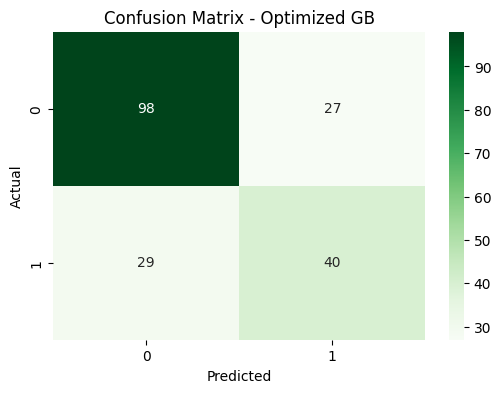

In [17]:
best_gb_cls = GradientBoostingClassifier(**best_params, random_state=42)
best_gb_cls.fit(X_train, y_train)

final_preds = best_gb_cls.predict(X_test)
final_probs = best_gb_cls.predict_proba(X_test)[:, 1]

acc_unscaled = accuracy_score(y_test, final_preds)
f1_unscaled = f1_score(y_test, final_preds)
roc_auc = roc_auc_score(y_test, final_probs)

print("Optimized GB Performance:")
print(f"Accuracy: {acc_unscaled:.4f}")
print(f"F1-Score: {f1_unscaled:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Optimized GB')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()